In [ ]:
import pandas as pd
import math
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pyvis.network import Network

In [ ]:
df = pd.read_csv("Email-Enron-undirected.csv")

G = nx.from_pandas_edgelist(df, source=df.columns[0], target=df.columns[1])

In [18]:
nx.is_connected(G)

False

In [19]:
lcc = list(nx.connected_components(G))[0]

# Subset of x% nodes with highest degree

In [20]:
A=G.copy()
x = 0.05
deg_list = sorted(A.degree(), key=lambda x: x[1], reverse=True)
k = math.ceil(x * len(deg_list))
remove = [n for n, d in deg_list[k:]]

A.remove_nodes_from(remove)

In [21]:
node, degree = max(A.degree(), key=lambda x: x[1])
print("Max degree:", degree)

Max degree: 550


# K-core Decomposition

Using network x, we obtain the k-core for every k

In [22]:
B = G.copy()
cores = []
i = 2

while len(B.nodes()) != 0:
    cores.append(B)
    B = nx.k_core(B, i)
    
    i += 1

print(len(cores[-1]))

275


In [23]:
[(i, len(c)) for (i, c) in enumerate(cores)]

[(0, 36692),
 (1, 25286),
 (2, 21309),
 (3, 15386),
 (4, 11648),
 (5, 9290),
 (6, 7061),
 (7, 5905),
 (8, 5088),
 (9, 4513),
 (10, 4126),
 (11, 3802),
 (12, 3530),
 (13, 3300),
 (14, 3062),
 (15, 2873),
 (16, 2707),
 (17, 2561),
 (18, 2416),
 (19, 2276),
 (20, 2162),
 (21, 2055),
 (22, 1944),
 (23, 1836),
 (24, 1731),
 (25, 1639),
 (26, 1553),
 (27, 1469),
 (28, 1367),
 (29, 1276),
 (30, 1170),
 (31, 1079),
 (32, 987),
 (33, 935),
 (34, 781),
 (35, 710),
 (36, 633),
 (37, 592),
 (38, 516),
 (39, 456),
 (40, 370),
 (41, 327),
 (42, 275)]

We select which one we want to study:

In [24]:
C = cores[max(range(len(cores)), key=lambda k: k * len(cores[k]))]
print(C)

Graph with 11648 nodes and 138578 edges


In [25]:
print(nx.is_connected(C))
print(len(list(nx.connected_components(C))))

False
15


We then extract the largest core component

In [26]:
largest_nodes = max(nx.connected_components(C), key=len)
D = C.subgraph(largest_nodes).copy()
print(D)
print(nx.is_connected(D))
print(nx.is_directed(G))

Graph with 11538 nodes and 138245 edges
True
False


# Network Analysis

We first get the number of nodes, edges and calculate the density

In [27]:
n_nodes = D.number_of_nodes()
print(n_nodes)
n_edges = D.number_of_edges()
print(n_edges)
density = nx.density(D)
print(density)

11538
138245
0.002077093282800972


Now we get the degree of each node, plot it and get the average degree

In [28]:
degrees = [D.degree(n) for n in D.nodes]
avg_degree = sum(degrees)/len(D)
print(avg_degree)

23.963425203674813


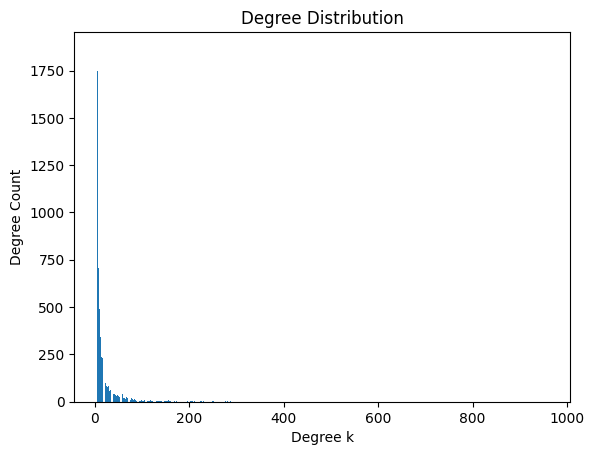

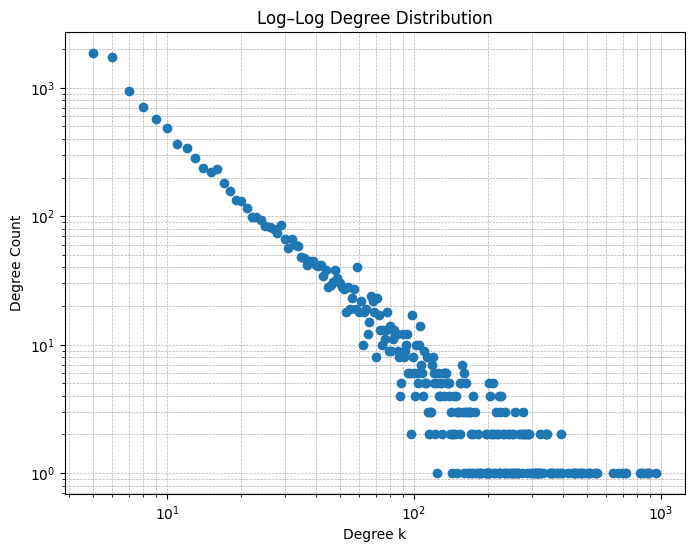

In [29]:
degree_counts = Counter(degrees)
min_degree, max_degree = min(degree_counts.keys()), max(degree_counts.keys())

#Plot the distribution
plot_x = list(range(min_degree, max_degree + 1))
plot_y = [degree_counts.get(x, 0) for x in plot_x]
plt.xlabel("Degree k")
plt.ylabel("Degree Count")
plt.title("Degree Distribution")
plt.bar(plot_x, plot_y)
plt.show()

# Plot on log–log scale
plt.figure(figsize=(8,6))
plt.loglog(plot_x, plot_y, marker='o', linestyle='none')
plt.xlabel("Degree k")
plt.ylabel("Degree Count")
plt.title("Log–Log Degree Distribution")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

Now we calculate the centralities and plot them

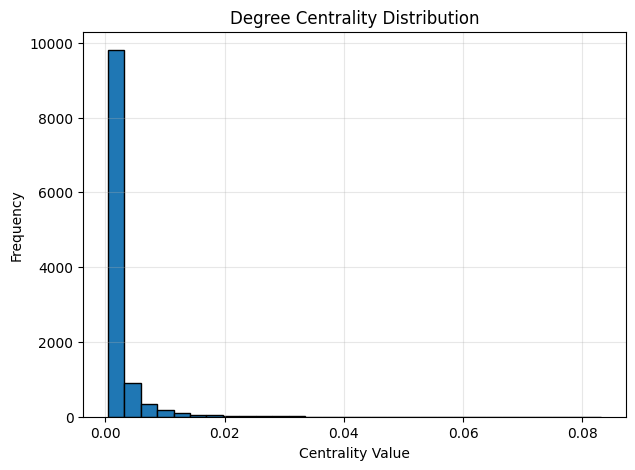

In [30]:
degree_centrality = nx.degree_centrality(D)
#print(degree_centrality)

values = list(degree_centrality.values())

plt.figure(figsize=(7,5))
plt.hist(values, bins=30, edgecolor='black')
plt.title("Degree Centrality Distribution")
plt.xlabel("Centrality Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

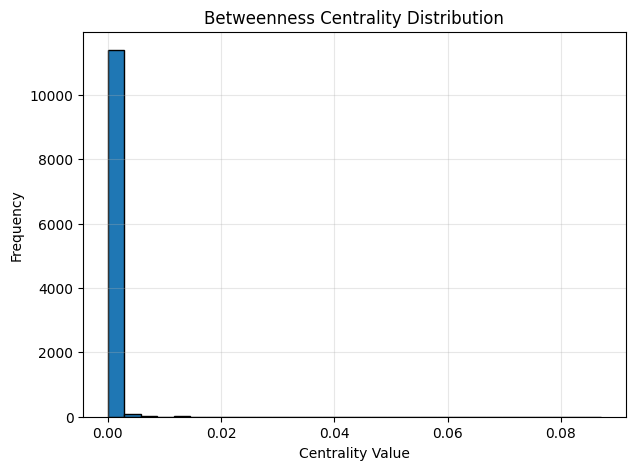

In [31]:
betweenness_centrality = nx.betweenness_centrality(D)
#print(betweenness_centrality)

values = list(betweenness_centrality.values())

plt.figure(figsize=(7,5))
plt.hist(values, bins=30, edgecolor='black')
plt.title("Betweenness Centrality Distribution")
plt.xlabel("Centrality Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

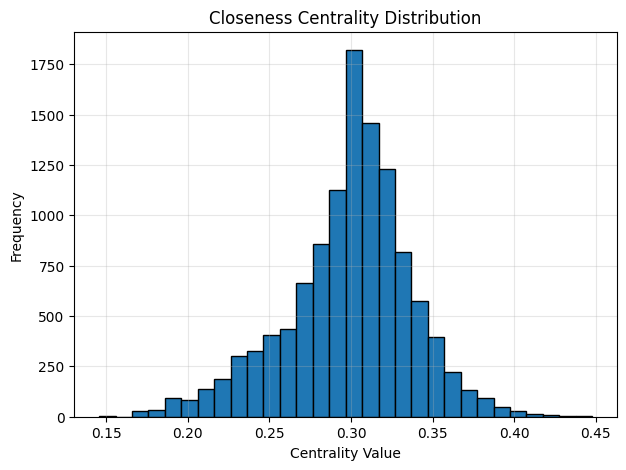

In [32]:
closeness_centrality = nx.closeness_centrality(D)
#print(closeness_centrality)

values = list(closeness_centrality.values())

plt.figure(figsize=(7,5))
plt.hist(values, bins=30, edgecolor='black')
plt.title("Closeness Centrality Distribution")
plt.xlabel("Centrality Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

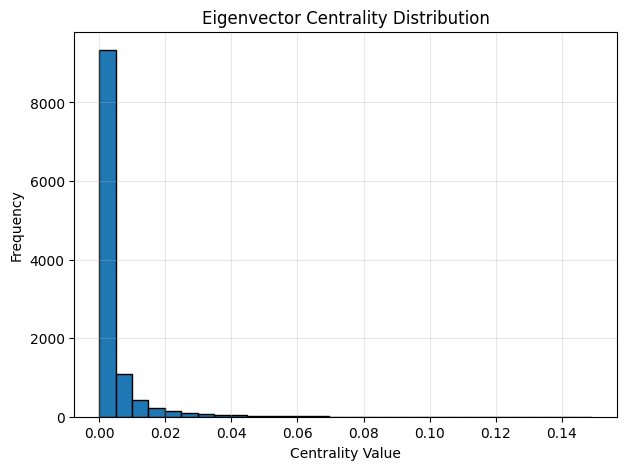

In [33]:
eigenvector_centrality = nx.eigenvector_centrality(D)
#print(eigenvector_centrality)

values = list(eigenvector_centrality.values())

plt.figure(figsize=(7,5))
plt.hist(values, bins=30, edgecolor='black')
plt.title("Eigenvector Centrality Distribution")
plt.xlabel("Centrality Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

Now we calculate the paths

In [34]:
avg_shortest_path = nx.average_shortest_path_length(D)
print(avg_shortest_path)
diameter = nx.diameter(D)
print(diameter)

3.410414791674733
9


Now we calculate the clustering and plot it

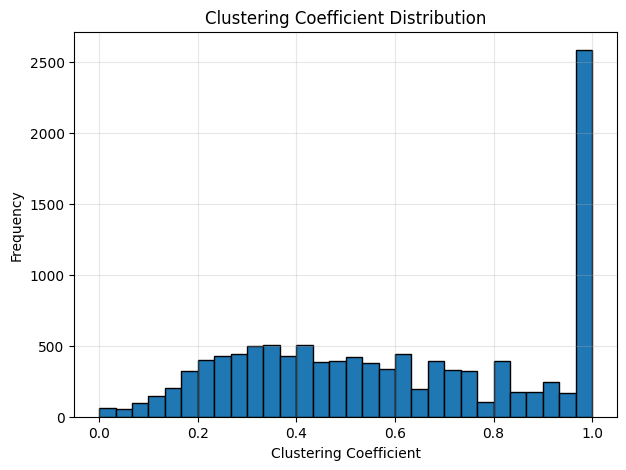

0.6001678066423783


In [35]:
clustering = nx.clustering(D)
#print(clustering)

values = list(clustering.values())

plt.figure(figsize=(7,5))
plt.hist(values, bins=30, edgecolor='black')
plt.title("Clustering Coefficient Distribution")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

avg_clustering = nx.average_clustering(D)
print(avg_clustering)

Now we proceed toward Community Detection

In [39]:
best_mod = -1
best_comm = None

for seed in range(10):
    comm = louvain_communities(D, seed=seed)
    mod = modularity(D, comm)
    if mod > best_mod:
        best_mod = mod
        best_comm = comm

communities = best_comm
print("Best modularity:", best_mod)
print("Number of communities:", len(communities))

Best modularity: 0.5519219309711104
Number of communities: 79


Now we represent the communities of the network

In [ ]:
node_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

num_communities = len(communities)
cmap = matplotlib.colormaps.get_cmap('tab20c')  # base colormap
colors = [mcolors.rgb2hex(cmap(i / num_communities)) for i in range(num_communities)]

# Map community ID → color
community_colors = {i: colors[i] for i in range(num_communities)}

net = Network(height="750px", width="100%", notebook=True, bgcolor="#222222", font_color="white")

for node in D.nodes():
    comm_id = node_community[node]
    net.add_node(node, 
                 label=str(node), 
                 title=f"Node {node}, Community {comm_id}",
                 color=community_colors[comm_id],
                 value=D.degree(node))  # size proportional to degree

# Add edges
for u, v in D.edges():
    net.add_edge(u, v)

net.force_atlas_2based() 
net.show("community_network.html")

C:\Users\emily\AppData\Local\Temp\ipykernel_17160\770803895.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')  # base colormap


KeyboardInterrupt: 